#Samuel Nathanael Sitompul

Sumber Data: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

## Preparation

### Menyiapkan Library yang Dibutuhkan

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV

### Menyiapkan dataset yang dibutuhkan

In [ ]:
df = pd.read_csv("Telco.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Deskripsi Fitur Dataset Telco Churn

### Identitas Pelanggan
- **customerID** : ID unik pelanggan

### Informasi Demografis
- **gender** : Jenis kelamin pelanggan (Male / Female)
- **SeniorCitizen** : Status lansia (1 = Ya, 0 = Tidak)
- **Partner** : Memiliki pasangan (Yes / No)
- **Dependents** : Memiliki tanggungan (Yes / No)

### Informasi Berlangganan
- **tenure** : Lama berlangganan (dalam bulan)
- **Contract** : Jenis kontrak (Month-to-month, One year, Two year)

### Layanan Telepon
- **PhoneService** : Berlangganan layanan telepon (Yes / No)
- **MultipleLines** : Memiliki lebih dari satu jalur telepon (Yes / No / No phone service)

### Layanan Internet
- **InternetService** : Jenis layanan internet (DSL, Fiber optic, No)
- **OnlineSecurity** : Layanan keamanan online (Yes / No / No internet service)
- **OnlineBackup** : Layanan backup online (Yes / No / No internet service)
- **DeviceProtection** : Perlindungan perangkat (Yes / No / No internet service)
- **TechSupport** : Dukungan teknis (Yes / No / No internet service)
- **StreamingTV** : Layanan streaming TV (Yes / No / No internet service)
- **StreamingMovies** : Layanan streaming film (Yes / No / No internet service)

### Informasi Pembayaran
- **PaperlessBilling** : Tagihan tanpa kertas (Yes / No)
- **PaymentMethod** : Metode pembayaran (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
- **MonthlyCharges** : Total biaya per bulan
- **TotalCharges** : Total biaya keseluruhan

### Target
- **Churn** : Status pelanggan berhenti berlangganan (Yes / No)

In [ ]:
df.shape

(7043, 21)

## Data Understanding

###Statistik Deskriptif

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


##EDA

###Korelasi Numerik

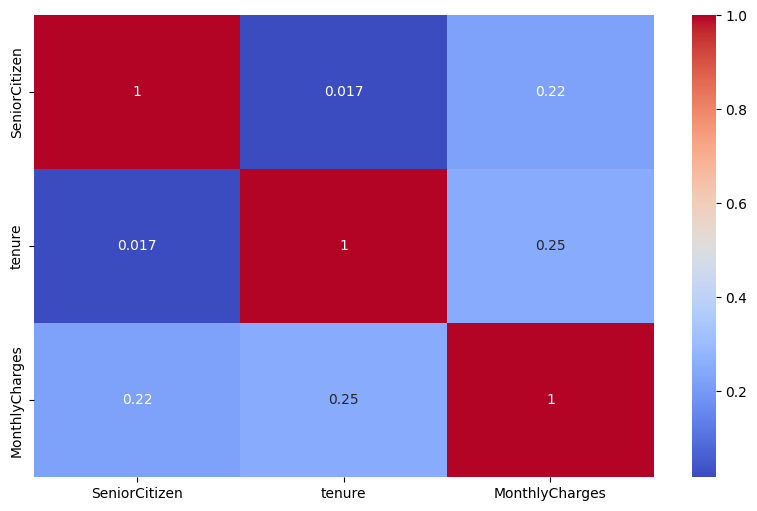

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

Dari heatmap korelasi, diperoleh hasil bahwa:

- SeniorCitizen vs tenure (0.017): Hampir tidak ada korelasi. Usia senior tidak berkaitan dengan lamanya berlangganan.
- SeniorCitizen vs MonthlyCharges (0.22): Korelasi positif lemah. Pelanggan senior cenderung membayar tagihan bulanan yang sedikit lebih tinggi, kemungkinan karena menggunakan lebih banyak layanan.
- tenure vs MonthlyCharges (0.25): Korelasi positif lemah. Pelanggan yang sudah lama berlangganan cenderung memiliki tagihan bulanan yang lebih tinggi, kemungkinan karena akumulasi layanan tambahan seiring waktu.

Secara keseluruhan, tidak ada korelasi kuat antar fitur numerik, sehingga risiko multikolinearitas tergolong rendah.

###Distribusi target (Churn)

<Axes: xlabel='Churn', ylabel='count'>

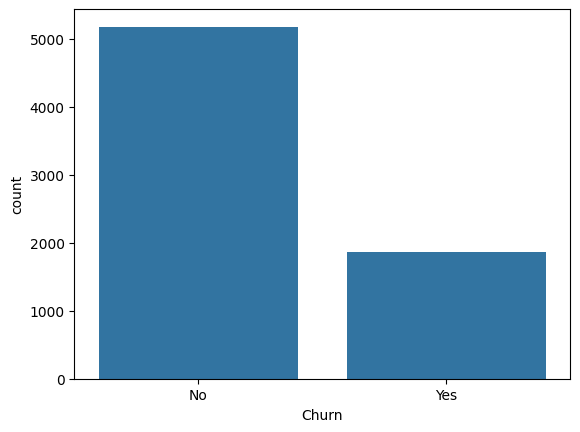

In [ ]:
sns.countplot(x='Churn', data=df)

Dari total data yang tersedia, terdapat sekitar 5.174 pelanggan yang tidak churn (No) dan 1.869 pelanggan yang churn (Yes).
Perbandingan ini menunjukkan bahwa dataset bersifat imbalanced (tidak seimbang) dengan rasio sekitar 73% : 27%. Kondisi ini perlu diantisipasi dalam pemodelan dan saya menggunakan parameter class_weight='balanced' agar model tidak bias hanya memprediksi kelas mayoritas (tidak churn).

###Distribusi fitur numerik terhadap Churn

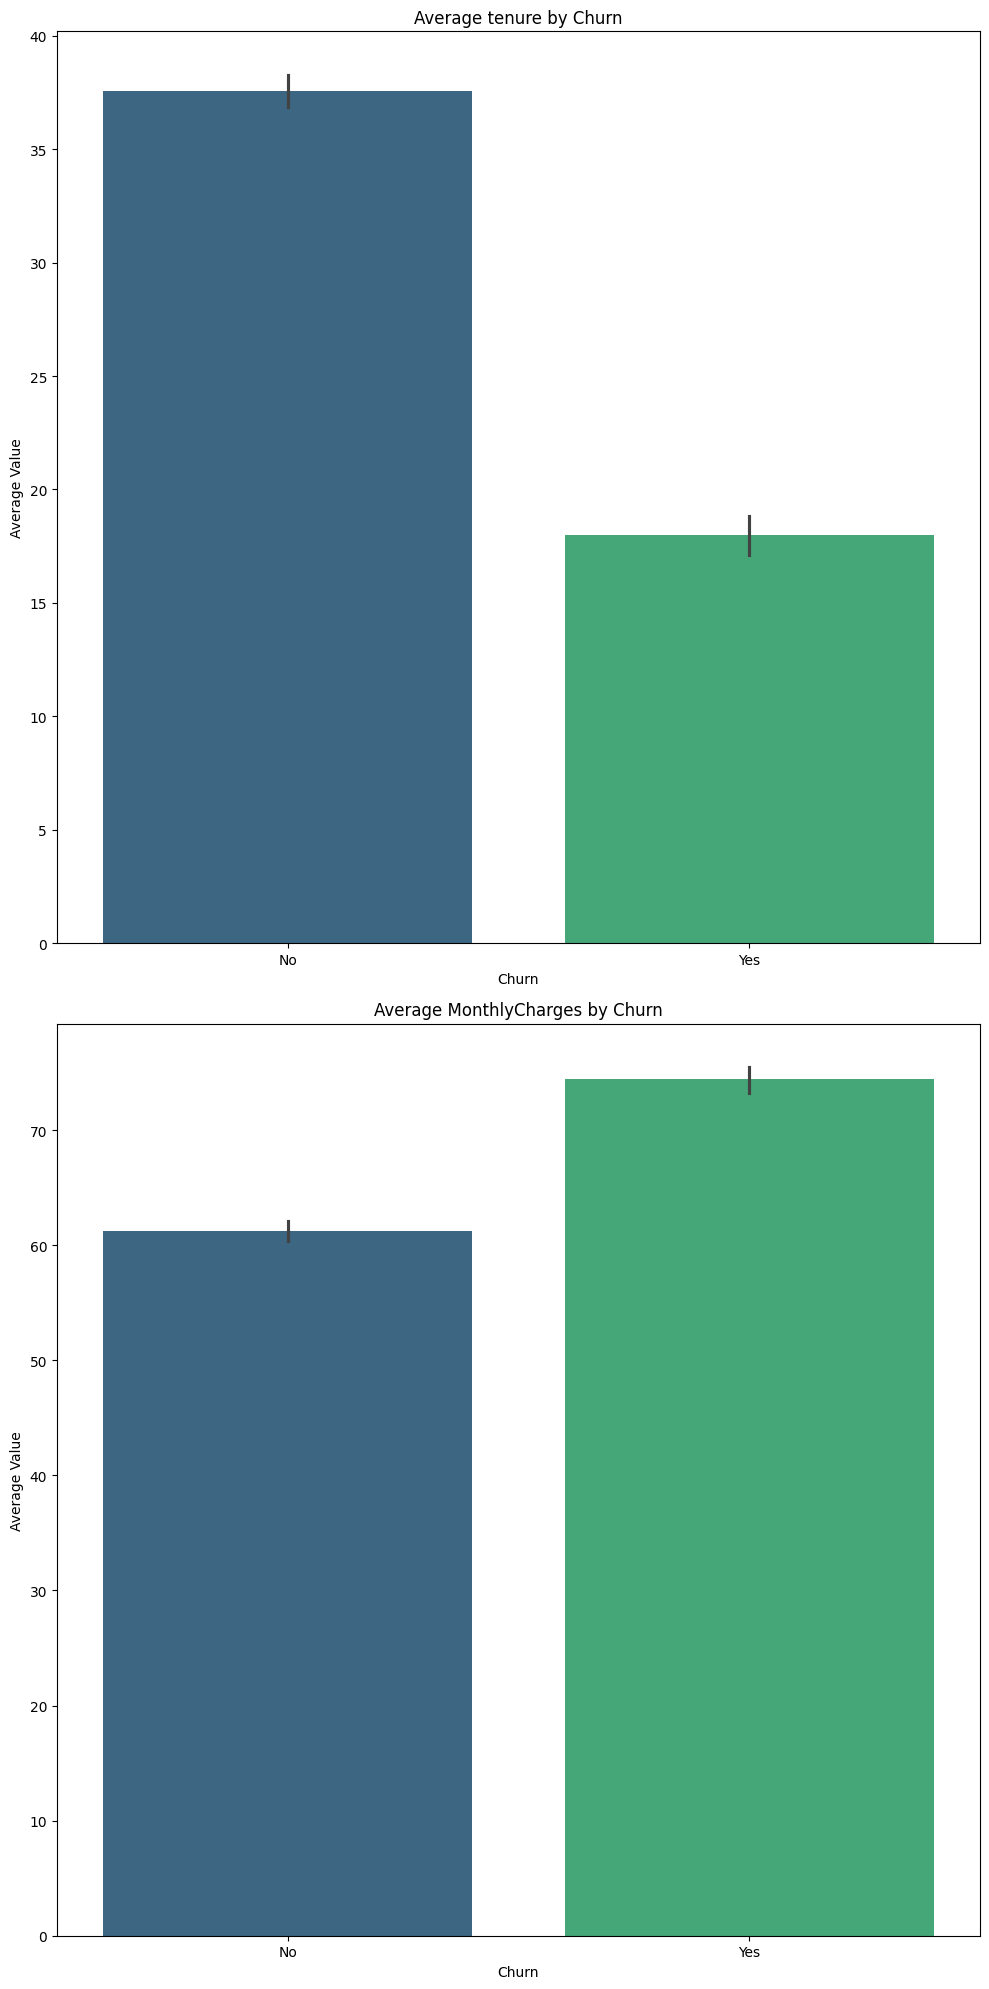

In [ ]:
def average_plot(features, df, segment_feature):
    fig, ax = plt.subplots(len(features), 1, figsize=(10, 20))

    for i, feature in enumerate(features):
        sns.barplot(
            data=df,
            x=segment_feature,
            y=feature,
            estimator=np.mean,
            errorbar=('ci', 95),
            ax=ax[i],
            palette="viridis"
        )
        ax[i].set_title(f'Average {feature} by {segment_feature}')
        ax[i].set_ylabel('Average Value')
        ax[i].set_xlabel(segment_feature)

    plt.tight_layout()
    plt.show()

average_plot(
    features=[
        'tenure',
        'MonthlyCharges'
    ],
    df=df,
    segment_feature="Churn"
)


- Tenure (Lama Berlangganan)
Pelanggan yang tidak churn memiliki rata-rata tenure sekitar 38 bulan, sedangkan pelanggan yang churn hanya sekitar 18 bulan.
Perbedaan yang sangat signifikan ini menunjukkan bahwa pelanggan baru jauh lebih rentan untuk berhenti berlangganan. Semakin lama seorang pelanggan bertahan, semakin besar kemungkinan mereka untuk tetap loyal. Ini mengindikasikan pentingnya program retensi di bulan-bulan awal berlangganan.
- Monthly Charges (Tagihan Bulanan)
Pelanggan yang churn memiliki rata-rata tagihan bulanan sekitar $74, lebih tinggi dibandingkan dengan yang tetap berlangganan
Temuan ini cukup menarik dengan menunjukkan bahwa yang membayar lebih mahal justru cenderung meninggalkan layanan. Hal ini mengindikasikan bahwa harga yang dirasakan tidak sebanding dengan nilai layanan yang diterima, sehingga pelanggan dengan tagihan tinggi lebih mudah berpindah ke kompetitor.

###Distribusi fitur kategorikal terhadap Churn

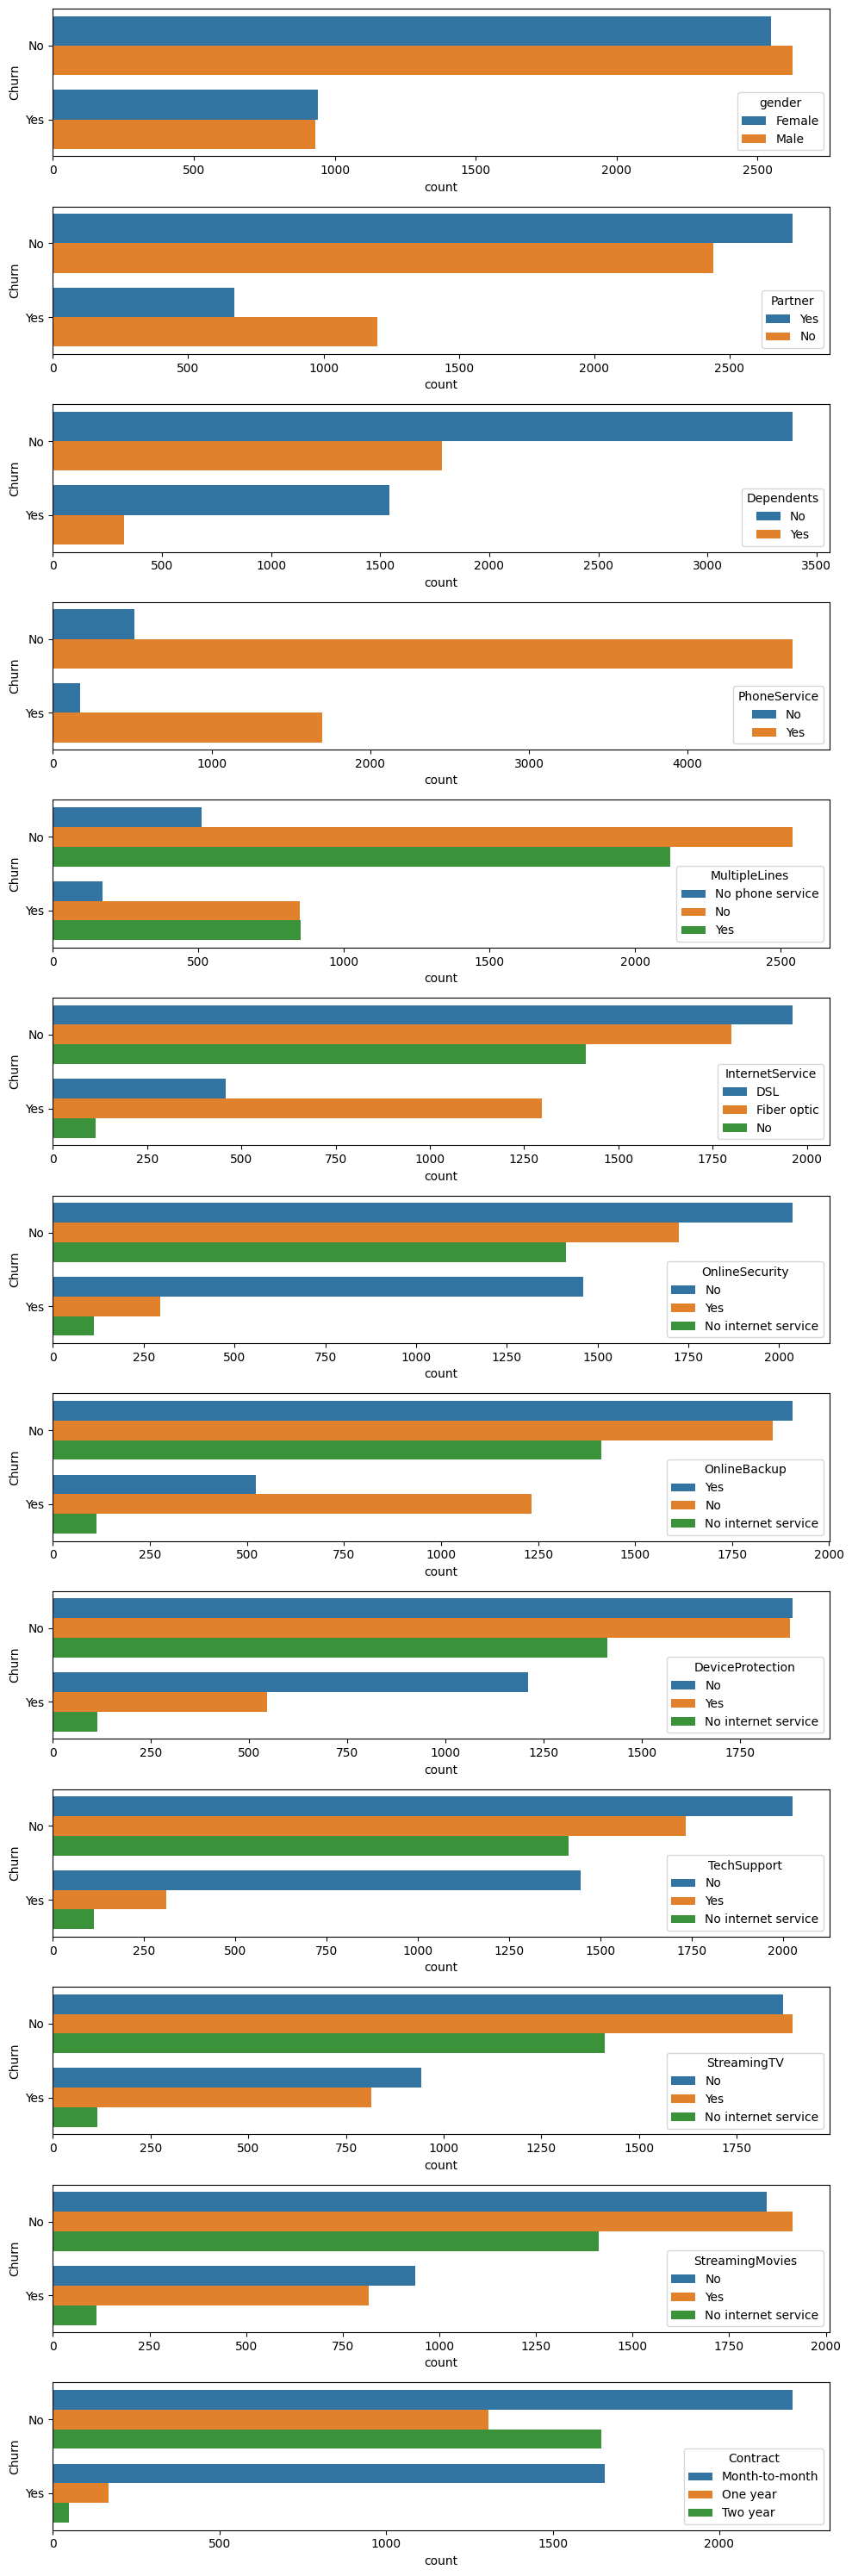

In [ ]:
def categorical_plot(features, df, segment_feature=None):
    fig, ax = plt.subplots(len(features), 1,figsize=(10,30))
    for i, feature in enumerate(features):
        if segment_feature:
            sns.countplot(data=df, y=segment_feature, hue=feature, ax=ax[i])
        else:
            sns.countplot(data=df, x=feature, ax=ax[i])
    plt.tight_layout()
    plt.show()

categorical_plot(
    features=[
        'gender',
        'Partner',
        'Dependents',
        'PhoneService',
        'MultipleLines',
        'InternetService',
        'OnlineSecurity',
        'OnlineBackup',
        'DeviceProtection',
        'TechSupport',
        'StreamingTV',
        'StreamingMovies',
        'Contract'
    ],
    df=df,
    segment_feature="Churn"
)

- Gender
Distribusi churn antara pelanggan pria dan wanita hampir seimbang. Tidak ada perbedaan yang signifikan antara kedua gender, sehingga gender bukan faktor penentu churn.
- Partner
Pelanggan yang tidak memiliki pasangan menunjukkan proporsi churn yang lebih tinggi dibanding pelanggan yang memiliki pasangan. Pelanggan dengan pasangan kemungkinan memiliki pertimbangan finansial bersama yang membuat mereka lebih loyal.
- Dependents
Pelanggan tanpa tanggungan memiliki proporsi churn yang jauh lebih tinggi. Pelanggan dengan tanggungan cenderung lebih stabil dan membutuhkan layanan jangka panjang.
- Phone Service
Mayoritas pelanggan yang churn maupun tidak churn memiliki layanan telepon, sehingga fitur ini tidak terlalu membedakan kedua kelompok.
- Multiple Lines
Tidak ada pola yang terlalu mencolok antara pelanggan dengan satu atau beberapa jalur telepon terhadap churn.
- Internet Service
Pelanggan dengan Fiber Optic mendominasi kelompok churn secara jumlah, melampaui pelanggan dengan DSL maupun tanpa internet. Ini mengindikasikan bahwa pelanggan Fiber Optic kurang puas dengan layanan yang diterima, kemungkinan karena ekspektasi kualitas yang tinggi namun tidak terpenuhi atau harga yang tidak kompetitif.
- Online Security
Pelanggan yang tidak memiliki layanan keamanan online mendominasi kelompok churn. Layanan ini tampaknya menjadi salah satu pembeda yaitu pelanggan tanpa perlindungan mungkin merasa kurang diperhatikan atau merasa paket mereka tidak lengkap.
- Online Backup, Device Protection, Tech Support
Pola serupa ditemukan pada ketiga fitur ini. Pelanggan tanpa layanan tambahan tersebut secara konsisten memiliki proporsi churn lebih tinggi. Ini menunjukkan bahwa bundling layanan tambahan berperan penting dalam meningkatkan loyalitas pelanggan.
- Streaming TV & Streaming Movies
Pelanggan yang tidak menggunakan layanan streaming memiliki proporsi churn yang lebih tinggi. Namun perbedaannya tidak setajam fitur layanan proteksi di atas.
- Contract
Hampir seluruh pelanggan yang churn berasal dari kontrak Month-to-Month, sementara pelanggan dengan kontrak One Year maupun Two Year sangat jarang churn. Hal ini sangat masuk akal karena pelanggan tanpa kontrak jangka panjang tidak memiliki ikatan finansial untuk bertahan, sehingga lebih mudah berpindah layanan kapan saja.

##DATA PREPARATION

###Validasi Data

####Mengganti Tipe data

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


####Cek Missing Value

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Data yang bernilai null hanya berjumlah 11 jadi bisa dilakukan drop untuk menghilangkan data yang bernilai null

In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


####Cek Duplikat

In [ ]:
df.duplicated().sum()

np.int64(0)

####Menghapus kolom tidak perlu

In [ ]:
df = df.drop(['customerID'], axis=1)

###Outlier Test

In [ ]:
numerical_columns = df.select_dtypes(include=['int64', 'float']).columns

In [ ]:
numerical_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')

In [ ]:
for col in numerical_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]

    print(f"{col} jumlah outlier: {len(outliers)}")

SeniorCitizen jumlah outlier: 1142
tenure jumlah outlier: 0
MonthlyCharges jumlah outlier: 0
TotalCharges jumlah outlier: 0


Tidak ditemukan outlier signifikan pada fitur tenure, MonthlyCharges, dan TotalCharges. SeniorCitizen tidak dihapus karena merupakan variabel biner (0/1), bukan outlier sejati.

##Feature Engineering

In [ ]:
df['charge_ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)

Mengukur rasio pembayaran bulanan terhadap total histori pembayaran

In [ ]:
df['tenure_group'] = pd.cut(df['tenure'],
                            bins=[0,12,24,60,72],
                            labels=['<1yr','1-2yr','2-5yr','5yr+'])

Menggabungkan nilai yang sama untuk memudahkan dalam menangkap pola nonlinear

In [ ]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,charge_ratio,tenure_group
6057,Male,0,No,No,19,Yes,No,DSL,No,No,...,Yes,No,Month-to-month,Yes,Credit card (automatic),61.55,1093.20,No,0.056251,1-2yr
4973,Male,1,Yes,No,13,Yes,Yes,Fiber optic,Yes,Yes,...,No,Yes,Month-to-month,No,Credit card (automatic),93.80,1261.00,No,0.074326,1-2yr
198,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Two year,Yes,Bank transfer (automatic),112.25,8041.65,No,0.013957,5yr+
3179,Female,0,No,No,27,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,Two year,Yes,Mailed check,19.60,561.15,No,0.034866,2-5yr
4436,Female,0,No,Yes,19,Yes,No,DSL,Yes,Yes,...,No,No,Month-to-month,Yes,Electronic check,60.60,1297.80,No,0.046658,1-2yr


##Split Data

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

##Encoding

In [ ]:
y_train = y_train.map({'Yes':1,'No':0})
y_test = y_test.map({'Yes':1,'No':0})

In [ ]:
binary_cols = ['gender','Partner','Dependents',
               'PhoneService','PaperlessBilling']

for col in binary_cols:
    X_train[col] = X_train[col].map({'Yes':1,'No':0,'Male':1,'Female':0})
    X_test[col] = X_test[col].map({'Yes':1,'No':0,'Male':1,'Female':0})

In [ ]:
service_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection',
                'TechSupport','StreamingTV','StreamingMovies','MultipleLines']

for col in service_cols:
    X_train[col] = X_train[col].replace({'No internet service':'No',
                                         'No phone service':'No'})
    X_test[col] = X_test[col].replace({'No internet service':'No',
                                       'No phone service':'No'})

    X_train[col] = X_train[col].map({'Yes':1,'No':0})
    X_test[col] = X_test[col].map({'Yes':1,'No':0})

In [ ]:
contract_map = {
    'Month-to-month':0,
    'One year':1,
    'Two year':2
}

X_train['Contract'] = X_train['Contract'].map(contract_map)
X_test['Contract'] = X_test['Contract'].map(contract_map)

In [ ]:
X_train = pd.get_dummies(X_train, columns=['InternetService','PaymentMethod', 'tenure_group'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['InternetService','PaymentMethod', 'tenure_group'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5625 entries, 1413 to 1505
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 5625 non-null   int64  
 1   SeniorCitizen                          5625 non-null   int64  
 2   Partner                                5625 non-null   int64  
 3   Dependents                             5625 non-null   int64  
 4   tenure                                 5625 non-null   int64  
 5   PhoneService                           5625 non-null   int64  
 6   MultipleLines                          5625 non-null   int64  
 7   OnlineSecurity                         5625 non-null   int64  
 8   OnlineBackup                           5625 non-null   int64  
 9   DeviceProtection                       5625 non-null   int64  
 10  TechSupport                            5625 non-null   int64  
 11  Stream

In [ ]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1407 entries, 974 to 2091
Data columns (total 26 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 1407 non-null   int64  
 1   SeniorCitizen                          1407 non-null   int64  
 2   Partner                                1407 non-null   int64  
 3   Dependents                             1407 non-null   int64  
 4   tenure                                 1407 non-null   int64  
 5   PhoneService                           1407 non-null   int64  
 6   MultipleLines                          1407 non-null   int64  
 7   OnlineSecurity                         1407 non-null   int64  
 8   OnlineBackup                           1407 non-null   int64  
 9   DeviceProtection                       1407 non-null   int64  
 10  TechSupport                            1407 non-null   int64  
 11  Streami

##Scaling Data

In [ ]:
feature_names = X_train.columns
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

##Modelling

###Logistic Regression

In [ ]:
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

param_grid = {
    "C": [0.001, 0.01, 0.1, 1, 10],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"],
    "class_weight": [None, "balanced"]
}

CV_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

CV_lr.fit(X_train, y_train)

best_lr_model = CV_lr.best_estimator_

print("Best Parameters:")
print(CV_lr.best_params_)

y_pred = best_lr_model.predict(X_test)
y_proba = best_lr_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print(f"\n  True Negatives  (TN): {cm[0,0]:4d}")
print(f"  False Positives (FP): {cm[0,1]:4d}")
print(f"  False Negatives (FN): {cm[1,0]:4d}")
print(f"  True Positives  (TP): {cm[1,1]:4d}")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nSUMMARY METRICS")
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.66      0.76      1033
           1       0.47      0.83      0.60       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.70      0.72      1407


Confusion Matrix:
[[678 355]
 [ 65 309]]

  True Negatives  (TN):  678
  False Positives (FP):  355
  False Negatives (FN):   65
  True Positives  (TP):  309

SUMMARY METRICS
Accuracy : 0.7015 (70.15%)
Precision: 0.4654
Recall   : 0.8262
F1-Score : 0.5954
ROC AUC  : 0.8422


Model Logistic Regression dengan parameter terbaik (C=0.001, class_weight='balanced', penalty='l2') meraih recall sebesar 82.62%, artinya model mampu mendeteksi lebih dari 8 dari 10 pelanggan yang benar-benar akan churn. Ini adalah nilai yang cukup baik mengingat konteks bisnis di mana melewatkan pelanggan churn (False Negative) jauh lebih merugikan daripada memprediksi churn secara berlebihan.
Namun, precision yang rendah (46.54%) menunjukkan bahwa hampir separuh pelanggan yang diprediksi churn ternyata tidak churn, sehingga upaya retensi akan banyak sia-sia ke pelanggan yang sebenarnya tidak perlu dipertahankan secara intensif.

Dari confusion matrix, model melewatkan hanya 65 pelanggan churn (FN), namun salah memprediksi 355 pelanggan tidak churn sebagai churn (FP). ROC AUC sebesar 0.8422 menunjukkan kemampuan diskriminasi model yang tergolong baik.

###Random Forest

In [ ]:
rf_model = RandomForestClassifier(
    random_state=123,
    n_jobs=-1,
    class_weight="balanced"
)

param_grid_fast = {
    "n_estimators": [200, 300],
    "max_depth": [6, 8, None],
    "max_features": ["sqrt"],
    "criterion": ["gini"]
}

CV_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_fast,
    cv=3,
    scoring="recall",
    n_jobs=-1,
    verbose=1
)

CV_rf.fit(X_train, y_train)

best_rf_model = CV_rf.best_estimator_

print("Best Parameters:", CV_rf.best_params_)
print("Best CV F1 Score:", CV_rf.best_score_)

y_pred = best_rf_model.predict(X_test)
y_pred_proba = best_rf_model.predict_proba(X_test)[:, 1]

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)
print(f"\n  True Negatives  (TN): {cm[0,0]}")
print(f"  False Positives (FP): {cm[0,1]}")
print(f"  False Negatives (FN): {cm[1,0]}")
print(f"  True Positives  (TP): {cm[1,1]}")

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc  = roc_auc_score(y_test, y_pred_proba)

print("\n" + "="*80)
print("SUMMARY METRICS (RANDOM FOREST)")
print("="*80)
print(f"Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 6, 'max_features': 'sqrt', 'n_estimators': 300}
Best CV F1 Score: 0.7926629698486666

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.72      0.81      1033
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1407
   macro avg       0.71      0.76      0.71      1407
weighted avg       0.80      0.74      0.76      1407


Confusion Matrix:
[[747 286]
 [ 75 299]]

  True Negatives  (TN): 747
  False Positives (FP): 286
  False Negatives (FN): 75
  True Positives  (TP): 299

SUMMARY METRICS (RANDOM FOREST)
Accuracy : 0.7434 (74.34%)
Precision: 0.5111
Recall   : 0.7995
F1-Score : 0.6236
ROC AUC  : 0.8409


Model Random Forest dengan parameter terbaik (max_depth=6, n_estimators=300, criterion='gini') memberikan performa yang lebih seimbang dibanding Logistic Regression.

Accuracy meningkat menjadi 74.34%, dan precision meningkat menjadi 51.11% yang berarti lebih dari setengah pelanggan yang diprediksi churn memang benar-benar churn. Recall sedikit menurun menjadi 79.95%, namun F1-Score yang lebih tinggi (0.6236 vs 0.5954) menunjukkan bahwa Random Forest mencapai keseimbangan yang lebih baik antara precision dan recall.

Dari confusion matrix, False Negative sedikit meningkat menjadi 75, namun False Positive berhasil ditekan menjadi 286 (dari 355 pada Logistic Regression). ROC AUC keduanya hampir setara di angka ~0.84.

##Keputusan Akhir

Random Forest dipilih sebagai model final karena memberikan akurasi, precision, dan F1-Score yang lebih baik secara keseluruhan. Meskipun recall Logistic Regression sedikit lebih tinggi, F1-Score Random Forest yang lebih unggul mencerminkan keseimbangan performa yang lebih optimal untuk diimplementasikan dalam strategi retensi pelanggan nyata.

##Feature Importances

FEATURE IMPORTANCE (RANDOM FOREST)
                           Feature  Importance
13                        Contract    0.240639
17                    charge_ratio    0.129875
4                           tenure    0.129572
18     InternetService_Fiber optic    0.106958
15                  MonthlyCharges    0.081767
16                    TotalCharges    0.063944
19              InternetService_No    0.053571
21  PaymentMethod_Electronic check    0.050522
25               tenure_group_5yr+    0.023284
7                   OnlineSecurity    0.017353
10                     TechSupport    0.014980
14                PaperlessBilling    0.014865
24              tenure_group_2-5yr    0.010118
3                       Dependents    0.007567
12                 StreamingMovies    0.007228


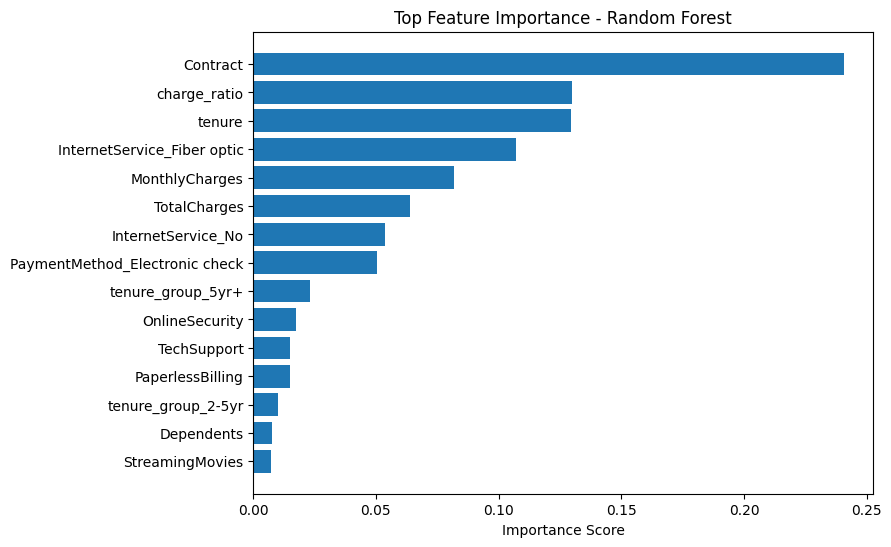

In [ ]:
print("FEATURE IMPORTANCE (RANDOM FOREST)")

importances = best_rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance.head(15))

top_features = feature_importance.head(15)

plt.figure(figsize=(8,6))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

Faktor-faktor yang paling berpengaruh terhadap prediksi churn:
- Contract (0.24)
Fitur paling dominan dengan importance score 0.24. Jenis kontrak adalah prediktor terkuat churn dengan pelanggan Month-to-Month jauh lebih berisiko meninggalkan layanan. Mengkonversi pelanggan ke kontrak jangka panjang adalah strategi retensi paling efektif.
- Charge Ratio (0.13)
Rasio antara tagihan bulanan dan total tagihan menjadi indikator penting. Nilai charge ratio yang tinggi menandakan pelanggan baru yang belum banyak membayar secara akumulatif, kelompok ini terbukti paling rentan churn.
- Tenure (0.13)
Lama berlangganan menempati posisi ketiga dengan importance setara charge ratio. Semakin pendek tenure, semakin tinggi risiko churn. Ini menegaskan bahwa fase kritis retensi ada di awal masa berlangganan.
- InternetService_Fiber Optic (0.11)
Pelanggan Fiber Optic memiliki risiko churn yang signifikan. Meski Fiber Optic adalah layanan premium, ketidakpuasan terhadap harga atau kualitas mendorong angka churn yang tinggi pada segmen ini.
- MonthlyCharges (0.08)
Tagihan bulanan yang tinggi berkorelasi dengan risiko churn yang lebih besar. Pelanggan dengan biaya bulanan di atas rata-rata perlu mendapat perhatian khusus dalam program retensi.
- TotalCharges (0.06)
Total akumulasi pembayaran berkontribusi dalam menentukan loyalitas pelanggan, meski pengaruhnya lebih kecil dibanding fitur di atas.
- InternetService_No & PaymentMethod_Electronic Check (0.05)
Pelanggan tanpa internet dan yang menggunakan metode pembayaran electronic check menunjukkan pola churn yang perlu dicermati. Electronic check kemungkinan berhubungan dengan pelanggan yang kurang terikat secara otomatis (berbeda dengan kartu kredit atau auto-debit).
- Fitur Lainnya (OnlineSecurity, TechSupport, PaperlessBilling, dll.)
Fitur-fitur ini memiliki importance yang lebih kecil namun tetap berkontribusi. Secara umum, ketiadaan layanan proteksi dan dukungan teknis sedikit meningkatkan risiko churn.

##Kesimpulan

Berdasarkan seluruh analisis, terdapat tiga faktor utama yang paling menentukan churn pelanggan Telco:

- Jenis Kontrak. Program insentif untuk mendorong pelanggan beralih dari Month-to-Month ke kontrak tahunan adalah intervensi paling berdampak.
- Tenure Rendah. Pelanggan di bawah 12 bulan pertama adalah kelompok paling rentan. Program onboarding dan engagement intensif di fase ini sangat direkomendasikan.
- Tagihan Tinggi tanpa Layanan Tambahan. Pelanggan dengan tagihan besar (terutama Fiber Optic) namun tidak berlangganan layanan proteksi atau dukungan teknis perlu ditawarkan bundling paket yang lebih komprehensif dan juga dapat meningkatkan performa dan pelayanan dari produk Fiber Optic itu sendiri.